<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Wrangling Lab**


Estimated time needed: **45** minutes


In this lab, you will perform data wrangling tasks to prepare raw data for analysis. Data wrangling involves cleaning, transforming, and organizing data into a structured format suitable for analysis. This lab focuses on tasks like identifying inconsistencies, encoding categorical variables, and feature transformation.


## Objectives


After completing this lab, you will be able to:


- Identify and remove inconsistent data entries.

- Encode categorical variables for analysis.

- Handle missing values using multiple imputation strategies.

- Apply feature scaling and transformation techniques.


#### Intsall the required libraries


In [1]:
!pip install pandas
!pip install matplotlib

## Tasks


#### Step 1: Import the necessary module.


### 1. Load the Dataset


<h5>1.1 Import necessary libraries and load the dataset.</h5>


Ensure the dataset is loaded correctly by displaying the first few rows.


In [2]:
# Import necessary libraries
import pandas as pd

# Load the Stack Overflow survey data
dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(dataset_url)

# Display the first few rows
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

#### 2. Explore the Dataset


<h5>2.1 Summarize the dataset by displaying the column data types, counts, and missing values.</h5>


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 195.7 MB

In [4]:
missing_values = df.isnull().sum()
print(missing_values)

ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10631
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 114, dtype: int64

In [5]:
#Sort missing values (most important insight)
missing_values.sort_values(ascending=False).head(20)

AINextMuch less integrated       64289
AINextLess integrated            63082
AINextNo change                  52939
AINextMuch more integrated       51999
EmbeddedAdmired                  48704
EmbeddedWantToWorkWith           47837
EmbeddedHaveWorkedWith           43223
ConvertedCompYearly              42002
AIToolNot interested in Using    41023
AINextMore integrated            41009
Knowledge_9                      37802
Frequency_3                      37727
Knowledge_8                      37679
ProfessionalTech                 37673
Knowledge_7                      37659
Knowledge_6                      37573
Knowledge_5                      37557
Knowledge_2                      37416
Knowledge_4                      37407
Knowledge_3                      37342
dtype: int64

The dataset contains both numerical and categorical variables with 114 columns and over 65,000 rows. The df.info() function shows data types and non-null counts, while df.isnull().sum() identifies missing values across columns. Several columns such as ConvertedCompYearly and CodingActivities contain a significant number of missing values, indicating the need for imputation or removal strategies before analysis.

<h5>2.2 Generate basic statistics for numerical columns.</h5>


In [6]:
df.describe()

,ResponseId,CompTotal,WorkExp,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,ConvertedCompYearly,JobSat
count,65437.000000,3.374000e+04,29658.000000,29324.000000,29393.000000,29411.000000,29450.000000,29448.00000,29456.000000,29456.000000,29450.000000,29445.000000,2.343500e+04,29126.000000
mean,32719.000000,2.963841e+145,11.466957,18.581094,7.522140,10.060857,24.343232,22.96522,20.278165,16.169432,10.955713,9.953948,8.615529e+04,6.935041
std,18890.179119,5.444117e+147,9.168709,25.966221,18.422661,21.833836,27.089360,27.01774,26.108110,24.845032,22.906263,21.775652,1.867570e+05,2.088259
min,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000
25%,16360.000000,6.000000e+04,4.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,3.271200e+04,6.000000
50%,32719.000000,1.100000e+05,9.000000,10.000000,0.000000,0.000000,20.000000,15.00000,10.000000,5.000000,0.000000,0.000000,6.500000e+04,7.000000
75%,49078.000000,2.500000e+05,16.000000,22.000000,5.000000,10.000000,30.000000,30.00000,25.000000,20.000000,10.000000,10.000000,1.079715e+05,8.000000
max,65437.000000,1.000000e+150,50.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,1.625660e+07,10.000000


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ResponseId,65437.0,3.271900e+04,1.889018e+04,1.0,16360.0,32719.0,49078.0,6.543700e+04
CompTotal,33740.0,2.963841e+145,5.444117e+147,0.0,60000.0,110000.0,250000.0,1.000000e+150
WorkExp,29658.0,1.146696e+01,9.168709e+00,0.0,4.0,9.0,16.0,5.000000e+01
JobSatPoints_1,29324.0,1.858109e+01,2.596622e+01,0.0,0.0,10.0,22.0,1.000000e+02
JobSatPoints_4,29393.0,7.522140e+00,1.842266e+01,0.0,0.0,0.0,5.0,1.000000e+02
JobSatPoints_5,29411.0,1.006086e+01,2.183384e+01,0.0,0.0,0.0,10.0,1.000000e+02
JobSatPoints_6,29450.0,2.434323e+01,2.708936e+01,0.0,0.0,20.0,30.0,1.000000e+02
JobSatPoints_7,29448.0,2.296522e+01,2.701774e+01,0.0,0.0,15.0,30.0,1.000000e+02
JobSatPoints_8,29456.0,2.027817e+01,2.610811e+01,0.0,0.0,10.0,25.0,1.000000e+02
JobSatPoints_9,29456.0,1.616943e+01,2.484503e+01,0.0,0.0,5.0,20.0,1.000000e+02


The df.describe() function was used to generate summary statistics for numerical columns. This includes measures such as mean, standard deviation, minimum, maximum, and quartiles. The results provide insights into the distribution of variables like compensation and work experience, highlighting variability and the presence of outliers in the dataset.

### 3. Identifying and Removing Inconsistencies


<h5>3.1 Identify inconsistent or irrelevant entries in specific columns (e.g., Country).</h5>


In [8]:
df['Country'].value_counts().head(20)

Country
United States of America                                11095
Germany                                                  4947
India                                                    4231
United Kingdom of Great Britain and Northern Ireland     3224
Ukraine                                                  2672
France                                                   2110
Canada                                                   2104
Poland                                                   1534
Netherlands                                              1449
Brazil                                                   1375
Italy                                                    1341
Australia                                                1260
Spain                                                    1123
Sweden                                                   1016
Russian Federation                                        925
Switzerland                                               876


In [10]:
#Check unique values count
df['Country'].nunique()

185

In [11]:
# Detect suspicious formatting issues: Leading/trailing spaces
df['Country'].str.strip().value_counts().head(20)

Country
United States of America                                11095
Germany                                                  4947
India                                                    4231
United Kingdom of Great Britain and Northern Ireland     3224
Ukraine                                                  2672
France                                                   2110
Canada                                                   2104
Poland                                                   1534
Netherlands                                              1449
Brazil                                                   1375
Italy                                                    1341
Australia                                                1260
Spain                                                    1123
Sweden                                                   1016
Russian Federation                                        925
Switzerland                                               876


In [12]:
df['Country'].isnull().sum()

np.int64(6507)

The Country column is largely consistent, with standardized naming conventions and no visible formatting issues. However, there are 6,507 missing values that may need to be handled depending on the analysis goal. These could be removed or imputed as "Unknown" if required.

<h5>3.2 Standardize entries in columns like Country or EdLevel by mapping inconsistent values to a consistent format.</h5>


In [13]:
# Standardizing Country column
df['Country'] = df['Country'].str.strip()

In [14]:
# Standardizing EdLevel
# Check unique values first:

df['EdLevel'].value_counts()

EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          24942
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       15557
Some college/university study without earning a degree                                 7651
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)     5793
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                         2970
Associate degree (A.A., A.S., etc.)                                                    1793
Primary/elementary school                                                              1146
Something else                                                                          932
Name: count, dtype: int64

In [15]:
# Basic cleanup (recommended)
df['EdLevel'] = df['EdLevel'].str.strip()

In [16]:
# simplify categories (for analysis)

# If you want cleaner grouping for visualization:

education_map = {
    "Bachelor’s degree (B.A., B.S., B.Eng., etc.)": "Bachelor",
    "Master’s degree (M.A., M.S., M.Eng., MBA, etc.)": "Master",
    "Some college/university study without earning a degree": "College_Incomplete",
    "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": "School",
    "Primary/elementary school": "School",
    "Associate degree (A.A., A.S., etc.)": "Associate",
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": "Professional",
    "Something else": "Other"
}

df['EdLevel_clean'] = df['EdLevel'].replace(education_map)

In [17]:
# Verify transformation
df['EdLevel_clean'].value_counts()

EdLevel_clean
Bachelor              24942
Master                15557
College_Incomplete     7651
School                 6939
Professional           2970
Associate              1793
Other                   932
Name: count, dtype: int64

The EdLevel column was successfully standardized into broader categories to simplify analysis. The transformation grouped similar education levels into meaningful clusters such as Bachelor, Master, School, and Professional. This reduces categorical complexity while preserving interpretability for further analysis and modeling.

### 4. Encoding Categorical Variables


<h5>4.1 Encode the Employment column using one-hot encoding.</h5>


One-hot encoding converts categorical text values into binary (0/1) columns, which is useful for analysis and machine learning.

In [18]:
# Apply One-Hot Encoding
employment_encoded = pd.get_dummies(df['Employment'], prefix='Employment')

# Add encoded columns to dataset
df = pd.concat([df, employment_encoded], axis=1)

In [19]:
# Verify encoding
employment_encoded.head()

,"Employment_Employed, full-time","Employment_Employed, full-time;Employed, part-time","Employment_Employed, full-time;Independent contractor, freelancer, or self-employed","Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time","Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time;Retired","Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work","Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work;Employed, part-time","Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work;Student, part-time","Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Retired","Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Student, part-time",...,"Employment_Student, full-time;Not employed, but looking for work;Not employed, and not looking for work;Student, part-time","Employment_Student, full-time;Not employed, but looking for work;Retired","Employment_Student, full-time;Not employed, but looking for work;Student, part-time","Employment_Student, full-time;Retired","Employment_Student, full-time;Student, part-time","Employment_Student, full-time;Student, part-time;Employed, part-time","Employment_Student, full-time;Student, part-time;Retired","Employment_Student, part-time","Employment_Student, part-time;Employed, part-time","Employment_Student, part-time;Retired"
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [20]:
# Check new columns created
employment_encoded.columns

Index(['Employment_Employed, full-time',
       'Employment_Employed, full-time;Employed, part-time',
       'Employment_Employed, full-time;Independent contractor, freelancer, or self-employed',
       'Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time',
       'Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time;Retired',
       'Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work',
       'Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work;Employed, part-time',
       'Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work;Student, part-time',
       'Employment_Employed, full-time;Independent contractor, freelancer, or self-employed;Retired',
       'Employment_Employed,

One-hot encoding was applied to the Employment column to convert categorical values into binary features. However, the column contained multiple employment statuses per row separated by semicolons, which resulted in encoding unique combinations rather than individual categories. This highlights the presence of multi-label categorical data that may require further preprocessing for more granular analysis.

### 5. Handling Missing Values


<h5>5.1 Identify columns with the highest number of missing values.</h5>


In [23]:
missing_counts = df.isnull().sum()
missing_counts.sort_values(ascending=False).head(20)

AINextMuch less integrated       64289
AINextLess integrated            63082
AINextNo change                  52939
AINextMuch more integrated       51999
EmbeddedAdmired                  48704
EmbeddedWantToWorkWith           47837
EmbeddedHaveWorkedWith           43223
ConvertedCompYearly              42002
AIToolNot interested in Using    41023
AINextMore integrated            41009
Knowledge_9                      37802
Frequency_3                      37727
Knowledge_8                      37679
ProfessionalTech                 37673
Knowledge_7                      37659
Knowledge_6                      37573
Knowledge_5                      37557
Knowledge_2                      37416
Knowledge_4                      37407
Knowledge_3                      37342
dtype: int64

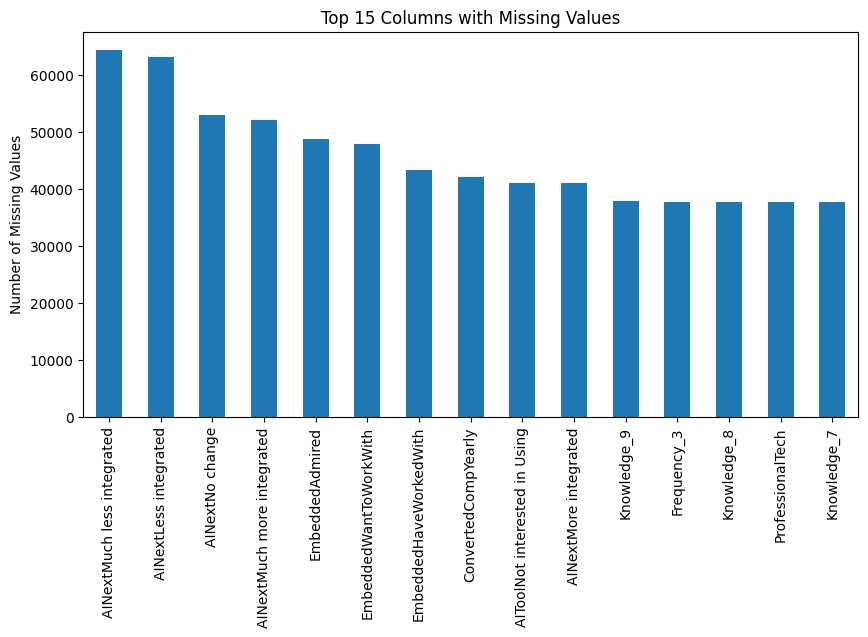

In [24]:
import matplotlib.pyplot as plt

missing_counts.sort_values(ascending=False).head(15).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 15 Columns with Missing Values")
plt.ylabel("Number of Missing Values")
plt.show()

<h5>5.2 Impute missing values in numerical columns (e.g., `ConvertedCompYearly`) with the mean or median.</h5>


In [25]:
df['ConvertedCompYearly'] = df['ConvertedCompYearly'].fillna(
    df['ConvertedCompYearly'].median()
)
# Verify imputation
df['ConvertedCompYearly'].isnull().sum()

np.int64(0)

<h5>5.3 Impute missing values in categorical columns (e.g., `RemoteWork`) with the most frequent value.</h5>


In [26]:
# Check missing values first
df['RemoteWork'].isnull().sum()

np.int64(10631)

In [27]:
df['RemoteWork'].mode()
df['RemoteWork'] = df['RemoteWork'].fillna(df['RemoteWork'].mode()[0])
# Verify imputation
df['RemoteWork'].isnull().sum()

np.int64(0)

### 6. Feature Scaling and Transformation


<h5>6.1 Apply Min-Max Scaling to normalize the `ConvertedCompYearly` column.</h5>


In [29]:
# Min-Max Scaling (Normalization)
df['ConvertedCompYearly_MinMax'] = (
    df['ConvertedCompYearly'] - df['ConvertedCompYearly'].min()
) / (
    df['ConvertedCompYearly'].max() - df['ConvertedCompYearly'].min()
)

# Verify
df[['ConvertedCompYearly', 'ConvertedCompYearly_MinMax']].head()

,ConvertedCompYearly,ConvertedCompYearly_MinMax
0,65000.0,0.003998
1,65000.0,0.003998
2,65000.0,0.003998
3,65000.0,0.003998
4,65000.0,0.003998


In [30]:
# Check range
df['ConvertedCompYearly_MinMax'].min(), df['ConvertedCompYearly_MinMax'].max()

(np.float64(0.0), np.float64(1.0))

<h5>6.2 Log-transform the ConvertedCompYearly column to reduce skewness.</h5>


In [31]:
# Log Transformation (Reduce Skewness)
import numpy as np

df['ConvertedCompYearly_Log'] = np.log1p(df['ConvertedCompYearly'])

# Verify
df[['ConvertedCompYearly', 'ConvertedCompYearly_Log']].head()

,ConvertedCompYearly,ConvertedCompYearly_Log
0,65000.0,11.082158
1,65000.0,11.082158
2,65000.0,11.082158
3,65000.0,11.082158
4,65000.0,11.082158


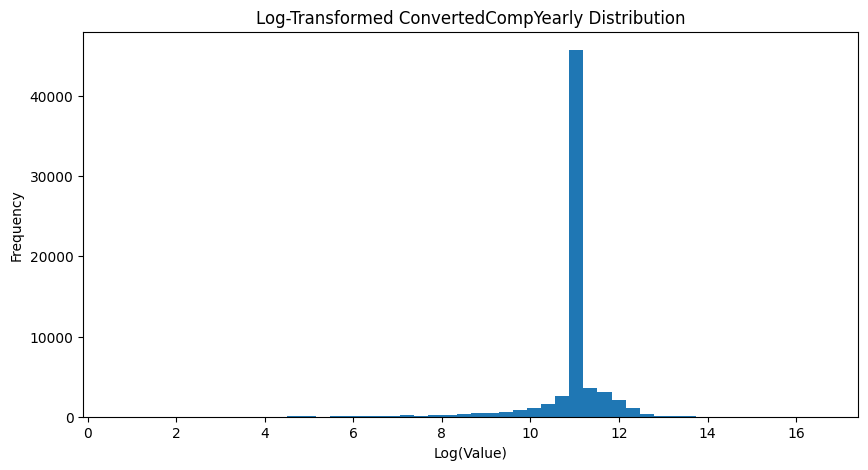

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
df['ConvertedCompYearly_Log'].plot(kind='hist', bins=50)

plt.title("Log-Transformed ConvertedCompYearly Distribution")
plt.xlabel("Log(Value)")
plt.ylabel("Frequency")
plt.show()

Min-Max scaling was applied to the ConvertedCompYearly column to normalize values into a range between 0 and 1. Additionally, a log transformation was applied using log1p to reduce skewness and minimize the impact of extreme values. These transformations improve data distribution and make the dataset more suitable for analysis and machine learning models.

### 7. Feature Engineering


<h5>7.1 Create a new column `ExperienceLevel` based on the `YearsCodePro` column:</h5>


Goal

Convert YearsCodePro into grouped experience levels such as:

Beginner
Intermediate
Experienced
Expert

In [33]:
# Inspect the column
df['YearsCodePro'].value_counts().head(20)

YearsCodePro
2                   4168
3                   4093
5                   3526
10                  3251
4                   3215
Less than 1 year    2856
6                   2843
1                   2639
8                   2549
7                   2517
12                  1777
15                  1635
20                  1549
9                   1493
11                  1312
13                  1127
14                  1082
25                   998
16                   946
18                   867
Name: count, dtype: int64

In [37]:
# Clean special values
df['YearsCodePro_clean'] = df['YearsCodePro'].replace({
    'Less than 1 year': 0.5,
    'More than 50 years': 50
})

In [38]:
# Convert to numeric
df['YearsCodePro_clean'] = pd.to_numeric(
    df['YearsCodePro_clean'],
    errors='coerce'
)

Create ExperienceLevel

In [44]:
def categorize_experience(x):
    if pd.isnull(x):
        return 'Unknown'
    elif x < 3:
        return 'Beginner'
    elif x < 7:
        return 'Intermediate'
    elif x < 15:
        return 'Experienced'
    else:
        return 'Expert'

In [45]:
df['ExperienceLevel'] = df['YearsCodePro_clean'].apply(categorize_experience)

In [46]:
# Verify transformation
df[['YearsCodePro', 'YearsCodePro_clean', 'ExperienceLevel']].head(10)

,YearsCodePro,YearsCodePro_clean,ExperienceLevel
0,NaN,NaN,Unknown
1,17,17.0,Expert
2,27,27.0,Expert
3,NaN,NaN,Unknown
4,NaN,NaN,Unknown
5,NaN,NaN,Unknown
6,7,7.0,Experienced
7,NaN,NaN,Unknown
8,NaN,NaN,Unknown
9,11,11.0,Experienced


logic is working exactly as intended:

< 3 → Beginner
3–6 → Intermediate
7–14 → Experienced
15+ → Expert
missing values → Unknown

A new feature called ExperienceLevel was successfully created from the YearsCodePro column. The original values were cleaned and converted into numeric format, and respondents were grouped into categories such as Beginner, Intermediate, Experienced, and Expert. Missing values were categorized as Unknown to preserve dataset completeness.

### Summary


In this lab, you:

- Explored the dataset to identify inconsistencies and missing values.

- Encoded categorical variables for analysis.

- Handled missing values using imputation techniques.

- Normalized and transformed numerical data to prepare it for analysis.

- Engineered a new feature to enhance data interpretation.


Copyright © IBM Corporation. All rights reserved.
